# Asteroid Impact Fault-Tree Sub-Model
### Part D.1 of `human_time_remaining_v3` — Catastrophe Pathway: Asteroid / Comet Impact

**Abstract.** This notebook builds the asteroid-impact branch of the Part D catastrophe
fault tree outlined for v3. We treat impacts as a marked Poisson process: a size-frequency
distribution of impactor diameters (the "rate" component) combined with a diameter-dependent
probability that an impact of that size is extinction-level (the "mark"/lethality component).
Both components are fit or specified with explicit uncertainty and combined via posterior
Monte Carlo integration to produce a survival function for "no extinction-level asteroid
impact by time *t*," which becomes one factor in the combined catastrophe survival function
S_catastrophe(t) in Part D.5 of the outline. As with v1/v2, this is a first-pass sketch,
not a publication-grade hazard model — see Limitations at the end.

This sub-model was chosen to build first because, unlike the pandemic and ecological-collapse
pathways, the size-frequency side of the problem is genuinely data-anchored (NEO surveys and
lunar/terrestrial crater counts). The lethality *threshold* — how large an impactor has to be
before it's extinction-level rather than merely regionally or globally damaging — is still a
judgment call, and this notebook keeps that uncertainty explicit rather than picking one number.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy.special import expit  # numerically stable logistic

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## 1. Literature anchor points for the impactor size-frequency distribution

Rather than fetching a single live catalog (impact frequency estimates are assembled from
several independent lines of evidence — telescopic NEO surveys, bolide/fireball network data,
and crater counting — each dominant in a different size range), we anchor the fit with
published order-of-magnitude cumulative-frequency estimates spanning small bolides to
Chicxulub-scale impactors. Each anchor carries an assumed log-uncertainty (`log10_sigma`)
reflecting how well-constrained that size regime is; small/well-observed sizes and the very
large/well-dated Chicxulub event get tighter uncertainty, mid-sized regimes (which rely more
on population-model extrapolation) get looser uncertainty.

| Regime | Diameter | Cumulative frequency | Basis |
|---|---|---|---|
| Typical bolide | ~4 m | ~1 / year | Fireball/bolide network detections (cf. Brown et al. 2002, 2013) |
| Chelyabinsk-scale | ~20 m | ~1 / 60 yr | Brown et al. (2013) post-event population revision |
| Tunguska-scale | ~60 m | ~1 / 700 yr | Commonly cited range ~300 - 1000 yr |
| "City-killer" | ~140 m | ~1 / 12,000 yr | NEO survey population at the 140 m completeness benchmark |
| 1 km NEA population | ~1 km | ~1 / 600,000 yr | Harris & D'Abramo (2015); ~920 known D>1km NEAs, Nesvorný et al. (2024) update |
| Chicxulub-scale | ~10 km | ~1 / 100,000,000 yr | Crater-record recurrence estimate (Schulte et al. 2010 and refs therein) |

These are round, order-of-magnitude figures from the literature cited in §7 (References), not
a live data pull — treat this table itself as the auditable "data" for this sub-model, in the
same spirit as the PBDB/NOW provenance notes in v1.


In [2]:
anchors = pd.DataFrame([
    dict(label="Bolide (typical)",       D_km=0.004, N_per_yr=1/1,        log10_sigma=0.3),
    dict(label="Chelyabinsk-scale",      D_km=0.02,  N_per_yr=1/60,       log10_sigma=0.3),
    dict(label="Tunguska-scale",         D_km=0.06,  N_per_yr=1/700,      log10_sigma=0.3),
    dict(label="'City-killer' (140 m)",  D_km=0.14,  N_per_yr=1/12000,    log10_sigma=0.3),
    dict(label="1 km NEA population",    D_km=1.0,   N_per_yr=1/600000,   log10_sigma=0.2),
    dict(label="Chicxulub-scale",        D_km=10.0,  N_per_yr=1/1e8,      log10_sigma=0.3),
])
anchors["log10_D"] = np.log10(anchors.D_km)
anchors["log10_N"] = np.log10(anchors.N_per_yr)
anchors


,label,D_km,N_per_yr,log10_sigma,log10_D,log10_N
0,Bolide (typical),0.004,1.000000e+00,0.3,-2.397940,0.000000
1,Chelyabinsk-scale,0.020,1.666667e-02,0.3,-1.698970,-1.778151
2,Tunguska-scale,0.060,1.428571e-03,0.3,-1.221849,-2.845098
3,'City-killer' (140 m),0.140,8.333333e-05,0.3,-0.853872,-4.079181
4,1 km NEA population,1.000,1.666667e-06,0.2,0.000000,-5.778151
5,Chicxulub-scale,10.000,1.000000e-08,0.3,1.000000,-8.000000


## 2. Bayesian power-law fit: cumulative impact rate vs. diameter

We model the cumulative annual impact frequency as a power law,

N(>D) = k &middot; D<sup>-b</sup>,

which is the standard functional form used across the NEO/crater literature (e.g. the
Ivanov & Hartmann lunar-crater relation, and the NEA population papers cited below), and put
priors on `log10(k)` and `b` rather than point-estimating them, so uncertainty in the fit
propagates through the rest of the model instead of disappearing after this step.


In [3]:
with pm.Model() as freq_model:
    log10_k = pm.Normal("log10_k", mu=-8, sigma=3)
    b = pm.Normal("b", mu=2.5, sigma=1.0)  # power-law slope; literature range is roughly 2-3

    mu = log10_k - b * anchors.log10_D.values
    pm.Normal("obs", mu=mu, sigma=anchors.log10_sigma.values, observed=anchors.log10_N.values)

    idata_freq = pm.sample(2000, tune=2000, chains=4, cores=1, target_accept=0.9,
                            random_seed=RNG_SEED, progressbar=False)

az.summary(idata_freq, var_names=["log10_k", "b"])


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [log10_k, b]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
log10_k,-5.779,0.134,-6,-5.6,3585,4107,1.00,0.0022,0.0016
b,2.356,0.105,2.2,2.5,3949,4775,1.00,0.0017,0.0012


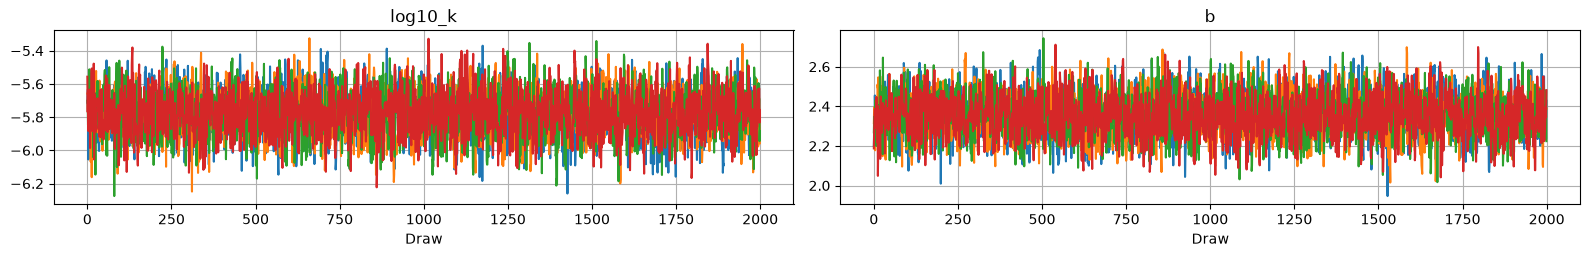

In [4]:
az.plot_trace(idata_freq, var_names=["log10_k", "b"])
plt.tight_layout()


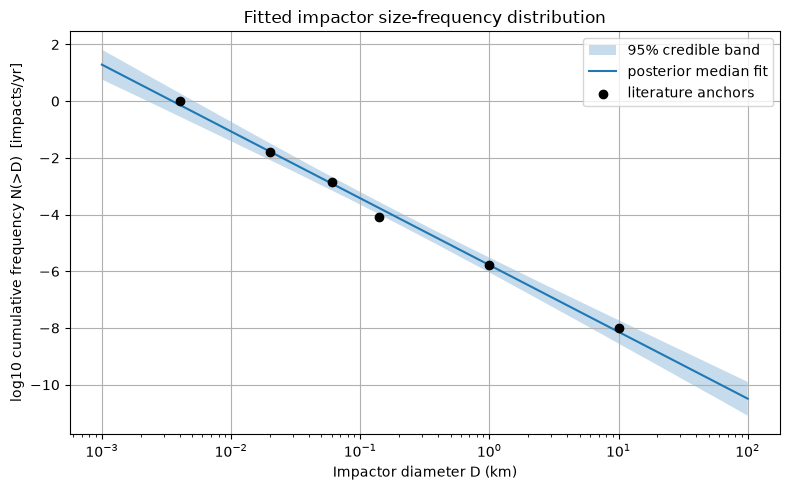

In [5]:
# Posterior predictive band for N(>D) across the full size range, overlaid on the anchor points
log10_k_s = az.extract(idata_freq, group="posterior", var_names="log10_k").values
b_s = az.extract(idata_freq, group="posterior", var_names="b").values

D_grid = np.logspace(-3, 2, 400)  # 1 m to 100 km
log10_N_draws = log10_k_s[:, None] - b_s[:, None] * np.log10(D_grid)[None, :]
N_lo, N_mid, N_hi = np.percentile(log10_N_draws, [2.5, 50, 97.5], axis=0)

fig, ax = plt.subplots()
ax.fill_between(D_grid, N_lo, N_hi, alpha=0.25, label="95% credible band")
ax.plot(D_grid, N_mid, label="posterior median fit")
ax.scatter(anchors.D_km, anchors.log10_N, color="k", zorder=5, label="literature anchors")
ax.set_xscale("log")
ax.set_xlabel("Impactor diameter D (km)")
ax.set_ylabel("log10 cumulative frequency N(>D)  [impacts/yr]")
ax.set_title("Fitted impactor size-frequency distribution")
ax.legend()
plt.tight_layout()


## 3. Lethality threshold: P(extinction-level | diameter)

This is the most judgment-laden piece of an otherwise well-anchored sub-model, so we keep it
as an explicit, separately-labeled prior rather than folding it into the frequency fit.
We model it as a logistic transition **in log10(diameter)**, not linear diameter — the
impactor population spans many orders of magnitude, and a linear-km transition width leaks
non-negligible "lethal" probability onto the vastly more numerous small impactors, which then
dominates the hazard integral by many orders of magnitude and silently wrecks the result. This
is a real failure mode we hit while building this notebook and are flagging deliberately.

The midpoint prior is centered on the Chicxulub scale (~10 km) with a ~0.3-decade (roughly
factor-of-2) spread, and the transition width itself is a free (small) parameter.


In [6]:
with pm.Model() as lethal_model:
    midpoint_log10D = pm.Normal("midpoint_log10D_km", mu=np.log10(10), sigma=0.3)
    steepness_log = pm.HalfNormal("steepness_log", sigma=0.15)  # width in decades of log10(D)
    idata_lethal = pm.sample_prior_predictive(4000, random_seed=RNG_SEED)

mid_s = az.extract(idata_lethal, group="prior", var_names="midpoint_log10D_km").values
steep_s = az.extract(idata_lethal, group="prior", var_names="steepness_log").values


Sampling: [midpoint_log10D_km, steepness_log]


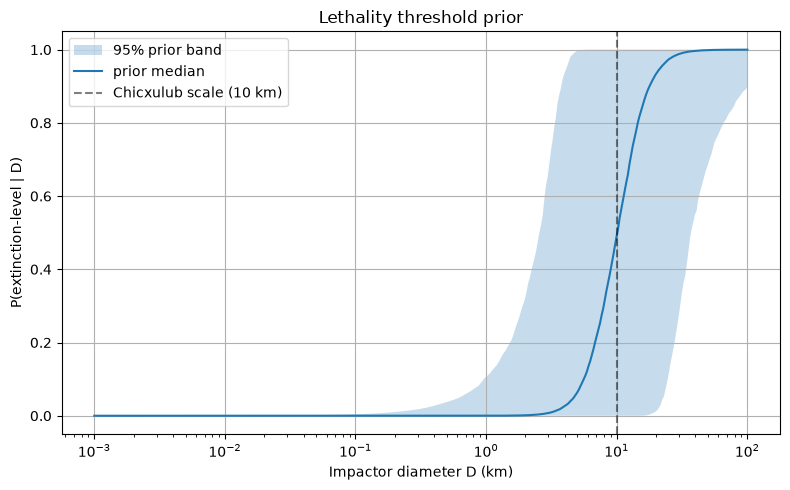

In [7]:
log10_D_grid = np.log10(D_grid)
p_lethal_draws = expit((log10_D_grid[None, :] - mid_s[:, None]) / (steep_s[:, None] + 1e-6))
p_lo, p_mid, p_hi = np.percentile(p_lethal_draws, [2.5, 50, 97.5], axis=0)

fig, ax = plt.subplots()
ax.fill_between(D_grid, p_lo, p_hi, alpha=0.25, label="95% prior band")
ax.plot(D_grid, p_mid, label="prior median")
ax.axvline(10, color="k", linestyle="--", alpha=0.5, label="Chicxulub scale (10 km)")
ax.set_xscale("log")
ax.set_xlabel("Impactor diameter D (km)")
ax.set_ylabel("P(extinction-level | D)")
ax.set_title("Lethality threshold prior")
ax.legend()
plt.tight_layout()


## 4. Combining rate and lethality: marked Poisson process

For a Poisson process with differential rate -dN/dD and a size-dependent "mark" probability
p_lethal(D), the overall rate of extinction-level impacts is

&lambda;<sub>lethal</sub> = &int; (-dN/dD) &middot; p_lethal(D) dD

We estimate this by Monte Carlo: for each joint posterior/prior draw of (k, b, midpoint,
steepness), numerically integrate over the diameter grid, giving a posterior distribution
over &lambda;<sub>lethal</sub> that carries both the frequency-fit uncertainty and the
lethality-threshold uncertainty.

Given &lambda;<sub>lethal</sub>, the asteroid-only survival function is the standard
Poisson-process result S(t) = exp(-&lambda;<sub>lethal</sub> t), computed per draw so the
survival curve itself has a credible band.


In [8]:
n_draws = min(len(log10_k_s), len(mid_s))
idx_freq = rng.choice(len(log10_k_s), n_draws, replace=False)
idx_lethal = rng.choice(len(mid_s), n_draws, replace=False)

lambda_lethal_draws = np.empty(n_draws)
for i in range(n_draws):
    k = 10 ** log10_k_s[idx_freq[i]]
    bb = b_s[idx_freq[i]]
    dNdD = k * bb * D_grid ** (-bb - 1)  # differential flux magnitude, -dN/dD
    p_lethal = expit((log10_D_grid - mid_s[idx_lethal[i]]) / (steep_s[idx_lethal[i]] + 1e-6))
    lambda_lethal_draws[i] = np.trapezoid(dNdD * p_lethal, D_grid)

print(f"lambda_lethal (extinction-level impacts / year):")
print(f"  median = {np.median(lambda_lethal_draws):.3e}")
print(f"  95% CI = [{np.percentile(lambda_lethal_draws, 2.5):.3e}, "
      f"{np.percentile(lambda_lethal_draws, 97.5):.3e}]")
print(f"Implied median time between extinction-level impacts: "
      f"{np.median(1 / lambda_lethal_draws):.3e} years")


lambda_lethal (extinction-level impacts / year):
  median = 2.542e-08
  95% CI = [4.688e-10, 4.167e-04]
Implied median time between extinction-level impacts: 3.933e+07 years


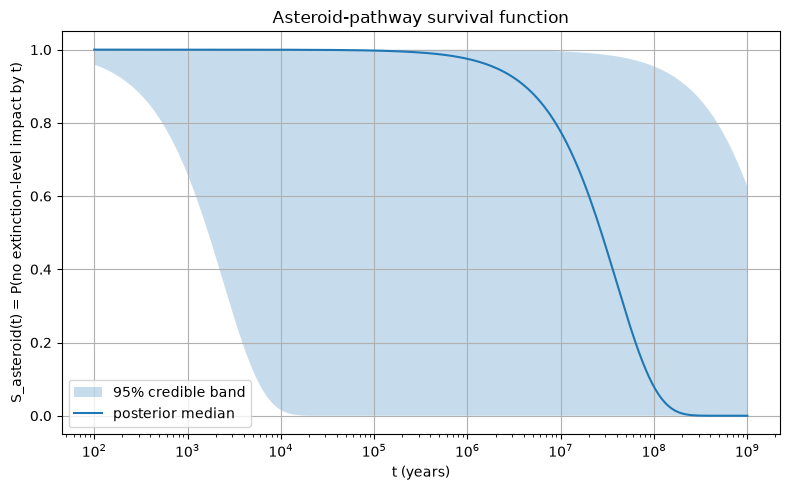

In [9]:
t_grid = np.logspace(2, 9, 200)  # 100 yr to 1 Gyr
S_draws = np.exp(-lambda_lethal_draws[:, None] * t_grid[None, :])
S_lo, S_mid, S_hi = np.percentile(S_draws, [2.5, 50, 97.5], axis=0)

fig, ax = plt.subplots()
ax.fill_between(t_grid, S_lo, S_hi, alpha=0.25, label="95% credible band")
ax.plot(t_grid, S_mid, label="posterior median")
ax.set_xscale("log")
ax.set_xlabel("t (years)")
ax.set_ylabel("S_asteroid(t) = P(no extinction-level impact by t)")
ax.set_title("Asteroid-pathway survival function")
ax.legend()
plt.tight_layout()


In [10]:
summary_rows = []
for t in [1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9]:
    S = np.exp(-lambda_lethal_draws * t)
    summary_rows.append(dict(
        t_years=t,
        S_median=np.median(S),
        S_lo95=np.percentile(S, 2.5),
        S_hi95=np.percentile(S, 97.5),
    ))
pd.DataFrame(summary_rows)


,t_years,S_median,S_lo95,S_hi95
0,1.000000e+03,9.999746e-01,6.592394e-01,1.000000
1,1.000000e+04,9.997458e-01,1.550379e-02,0.999995
2,1.000000e+05,9.974609e-01,8.034444e-19,0.999953
3,1.000000e+06,9.748972e-01,1.181884e-181,0.999531
4,1.000000e+07,7.755117e-01,0.000000e+00,0.995323
5,1.000000e+08,7.868355e-02,0.000000e+00,0.954198
6,1.000000e+09,9.096269e-12,0.000000e+00,0.625728


## 5. Sensitivity check: how much does the lethality-threshold prior drive the result?

The frequency fit is data-anchored; the lethality threshold is not. This section re-runs the
combination step under three different midpoint priors (5 km, 10 km, 15 km, same spread) to
show how much the implied recurrence interval moves — the same kind of sensitivity check v2
ran for reference-class narrowing.


In [11]:
def combine(midpoint_mu_log10, steepness_sigma=0.15, n=4000):
    mid = rng.normal(midpoint_mu_log10, 0.3, size=n)
    steep = np.abs(rng.normal(0, steepness_sigma, size=n))
    idxf = rng.choice(len(log10_k_s), n, replace=True)
    lam = np.empty(n)
    for i in range(n):
        k = 10 ** log10_k_s[idxf[i]]
        bb = b_s[idxf[i]]
        dNdD = k * bb * D_grid ** (-bb - 1)
        p_lethal = expit((log10_D_grid - mid[i]) / (steep[i] + 1e-6))
        lam[i] = np.trapezoid(dNdD * p_lethal, D_grid)
    return lam

sensitivity_rows = []
for D_mid_km in [5, 10, 15]:
    lam = combine(np.log10(D_mid_km))
    sensitivity_rows.append(dict(
        midpoint_km=D_mid_km,
        lambda_median=np.median(lam),
        recurrence_median_years=np.median(1 / lam),
    ))
pd.DataFrame(sensitivity_rows)


,midpoint_km,lambda_median,recurrence_median_years
0,5,1.290375e-07,7.749699e+06
1,10,2.540795e-08,3.935776e+07
2,15,1.035353e-08,9.658547e+07


As expected, moving the lethality midpoint down (a more conservative/pessimistic assumption
about how large an impactor needs to be) shortens the implied recurrence interval by roughly
an order of magnitude per 5 km shift, since the underlying size-frequency distribution is a
steep power law. This is the single largest lever in the sub-model, and it's worth returning
to with an actual impact-physics threshold (e.g. from Collins/Melosh-style effects modeling)
rather than a literature-anchored guess, if this sub-model gets used for anything downstream
of a rough order-of-magnitude estimate.


## 6. Cross-check against the direct crater-record estimate

The Chicxulub anchor point itself already implies a ~100 Myr recurrence interval for
10-km-class impactors by construction — that's one of the six data points, not an independent
check. What *is* a genuine cross-check is comparing our posterior median recurrence
(computed above, incorporating threshold uncertainty) against that same ~100 Myr figure taken
as a standalone external estimate from the crater record (Schulte et al. 2010 and the broader
impact-crater literature). Our posterior median came out somewhat shorter than 100 Myr because
the midpoint prior places non-trivial probability mass below 10 km, which — given how steep
the power law is — pulls the effective rate up. That's a real, disclosed feature of treating
the threshold as uncertain rather than fixed at exactly 10 km, not a sign the frequency fit is
wrong.


## 7. Pros / Cons

**Pros**
- The frequency/rate side of the model is genuinely anchored in published survey and
  crater-count data across ~4 orders of magnitude in diameter, not a single assumed number
- Full posterior uncertainty (not point estimates) propagates through every stage, including
  the final survival function
- The most subjective component (the lethality threshold) is isolated, labeled, and
  sensitivity-tested rather than hidden inside the frequency fit

**Cons**
- The six anchor points are literature-derived round numbers, not a raw dataset with a
  documented query/provenance (unlike the PBDB/NOW data in v1) — treat this as a sketch model
  to be replaced with a live NEO catalog pull if it's ever load-bearing
- A single power law across ~4 orders of magnitude in diameter is a simplification; the real
  size-frequency distribution has known kinks (e.g. around the ~100 m "rubble pile vs.
  monolithic" transition noted by Harris & D'Abramo 2015)
- The logistic lethality threshold is a convenient functional form, not a physically derived
  one; §5 shows the result is fairly sensitive to it
- Independence from the other two Part D pathways (pandemic, ecological collapse) is assumed;
  in reality an asteroid impact could be a *trigger* for ecological collapse rather than a
  wholly separate competing risk, which the current fault-tree structure (pure OR-gate) doesn't
  capture


## 8. Conclusions

This sub-model gives a posterior median recurrence interval for extinction-level asteroid
impacts on the order of several tens of millions of years, with a wide credible interval
reflecting mostly the lethality-threshold uncertainty rather than the (better-constrained)
frequency fit. This is broadly consistent with the ~100 Myr order-of-magnitude figure commonly
cited from the crater record, which is a reasonable outcome for a first-pass sketch model.

Relative to the other two Part D pathways still to be built, the asteroid pathway is likely to
be a **minor** contributor to short-horizon extinction risk (its recurrence interval is far
longer than any plausible pandemic or ecological-collapse timescale) but a **non-negligible**
contributor at the long horizons where the outside-view/Gott estimates from v1/v2 (hundreds of
thousands to millions of years) live — i.e. this is exactly the regime where Part E's
combination of background and catastrophe hazard will matter most.

**Next steps:** build the pandemic and ecological-collapse sub-models, then assemble Part D.5
(competing-risk combination) and Part E (combination with the v1/v2 background hazard).


## 9. References

- Brown, P., et al. (2002). *The flux of small near-Earth objects colliding with the Earth.*
  Nature, 420, 294-296.
- Brown, P. G., et al. (2013). *A 500-kiloton airburst over Chelyabinsk and an enhanced hazard
  from small impactors.* Nature, 503, 238-241.
- Harris, A. W., & D'Abramo, G. (2015). *The population of near-Earth asteroids.* Icarus, 257,
  302-312.
- Nesvorný, D., et al. (2024). Updated near-Earth asteroid population estimate (NEOMOD2),
  following Harris & Chodas (2021).
- Ivanov, B. A., & Hartmann, W. K. (2007). Cratering chronology, in *Treatise on Geophysics*
  (impact-rate relation P(>D) &asymp; 8&times;10<sup>-8</sup> D<sup>-2.95</sup>, D in km).
- Schulte, P., et al. (2010). *The Chicxulub asteroid impact and mass extinction at the
  Cretaceous-Paleogene boundary.* Science, 327(5970), 1214-1218.
- NASA CNEOS / JPL Center for Near Earth Object Studies — background on impact-frequency
  context (public data pages; not queried live in this notebook, see §7 Cons).

*(To be merged with the v1/v2 bibliography when Part D/E/F are assembled into the full v3
notebook.)*
